<a href="https://colab.research.google.com/github/jlvi179/Advanced-Deep-Learning/blob/main/submission1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


labels.npy:   0%|          | 0.00/285k [00:00<?, ?B/s]

spectra.npy:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

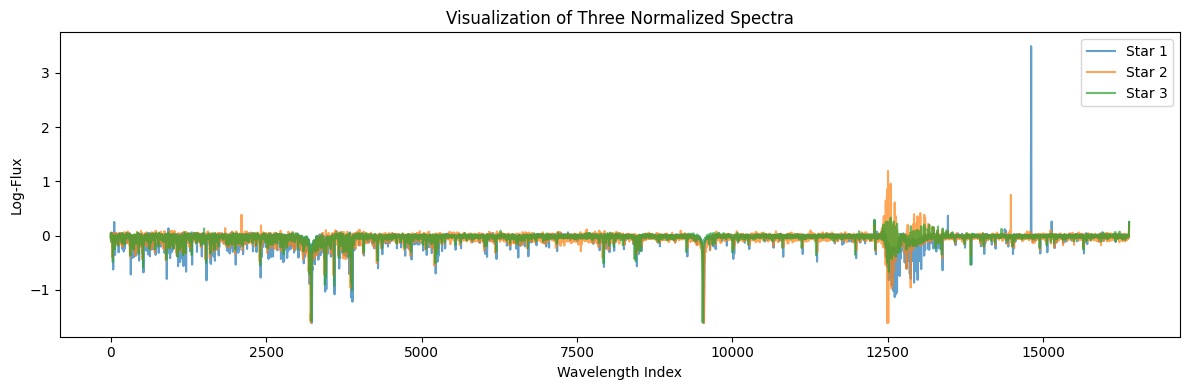

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download  # not really necessary since data could simply be downloaded manually and added to folder.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


'''
==========================================
1. Data Download and Preparation
=========================================
'''

print("Downloading data")
data_path = "."
hf_hub_download(repo_id="simbaswe/galah4", filename="labels.npy", repo_type="dataset", local_dir=data_path)
hf_hub_download(repo_id="simbaswe/galah4", filename="spectra.npy", repo_type="dataset", local_dir=data_path)

spectra = np.load(f"{data_path}/spectra.npy")
labels_raw = np.load(f"{data_path}/labels.npy")

# Use only t_eff, log_g, fe_h (columns -4 to -1)
labels = labels_raw[:, -4:-1]
label_names = ["t_eff", "log_g", "fe_h"]

# Normalize spectra (as specified)
spectra = np.log(np.maximum(spectra, 0.2))

# Normalize labels (very important for MSE loss!)
scaler = StandardScaler()
labels_scaled = scaler.fit_transform(labels)

# Train/test split (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(spectra, labels_scaled, test_size=0.2, random_state=42)

'''
==========================================
2. Visualization of Example Spectra
==========================================
'''

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.plot(X_train[i], label=f"Star {i+1}", alpha=0.7)
plt.title("Visualization of Three Normalized Spectra")
plt.xlabel("Wavelength Index")
plt.ylabel("Log-Flux")
plt.legend()
plt.tight_layout()
plt.show()




This plot displays the pre-processed input data for three random stars from the training set. The y-axis shows the log-scaled flux, and the x-axis represents the wavelength index. It serves as a sanity check to confirm that the normalization process was successful and that the spectral features (absorption lines) are preserved and fed correctly into the CNN.

Training on: cuda
Starting training...
Epoch 1/15 | Train Loss: 0.5218 | Test Loss: 0.1491
Epoch 2/15 | Train Loss: 0.1502 | Test Loss: 0.0826
Epoch 3/15 | Train Loss: 0.1075 | Test Loss: 0.0660
Epoch 4/15 | Train Loss: 0.0935 | Test Loss: 0.0524
Epoch 5/15 | Train Loss: 0.0898 | Test Loss: 0.0599
Epoch 6/15 | Train Loss: 0.0839 | Test Loss: 0.0663
Epoch 7/15 | Train Loss: 0.0816 | Test Loss: 0.0475
Epoch 8/15 | Train Loss: 0.0792 | Test Loss: 0.0442
Epoch 9/15 | Train Loss: 0.0753 | Test Loss: 0.0424
Epoch 10/15 | Train Loss: 0.0743 | Test Loss: 0.0445
Epoch 11/15 | Train Loss: 0.0714 | Test Loss: 0.0420
Epoch 12/15 | Train Loss: 0.0715 | Test Loss: 0.0474
Epoch 13/15 | Train Loss: 0.0698 | Test Loss: 0.0395
Epoch 14/15 | Train Loss: 0.0696 | Test Loss: 0.0367
Epoch 15/15 | Train Loss: 0.0699 | Test Loss: 0.0505


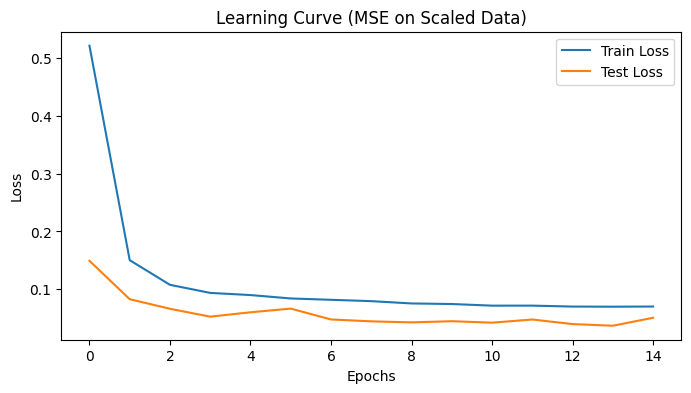

In [ ]:
'''
==========================================
3. PyTorch Dataset & DataLoader
=========================================
'''
class StarDataset(Dataset):
    def __init__(self, X, y):
        # PyTorch Conv1d expects inputs in the form (batch, channels, length)
        # Since we have 1D data, we add a channel dimension
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StarDataset(X_train, y_train)
test_dataset = StarDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

'''
==========================================
4. CNN Model Architecture
==========================================
'''

class SpectraCNN(nn.Module):
    def __init__(self):
        super(SpectraCNN, self).__init__()
        # Input: (batch, 1, 16384)
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4), # Length now: ~2048

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4), # Length now: ~256

            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4)  # Length now: ~64
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3) # 3 outputs: t_eff, log_g, fe_h
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = SpectraCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

'''
==========================================
5. Training Loop
==========================================
'''

epochs = 15
train_losses = []
test_losses = []

print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()

    test_losses.append(test_loss / len(test_loader))
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f}")

# Plot learning curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Learning Curve (MSE on Scaled Data)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


This graph tracks the Mean Squared Error (MSE) loss for both the training and test datasets across the 15 training epochs. The downward trend of both curves indicates that the model is actively learning. The proximity of the test loss to the train loss suggests that the dropout layers are effectively preventing the model from memorizing the training data (overfitting).

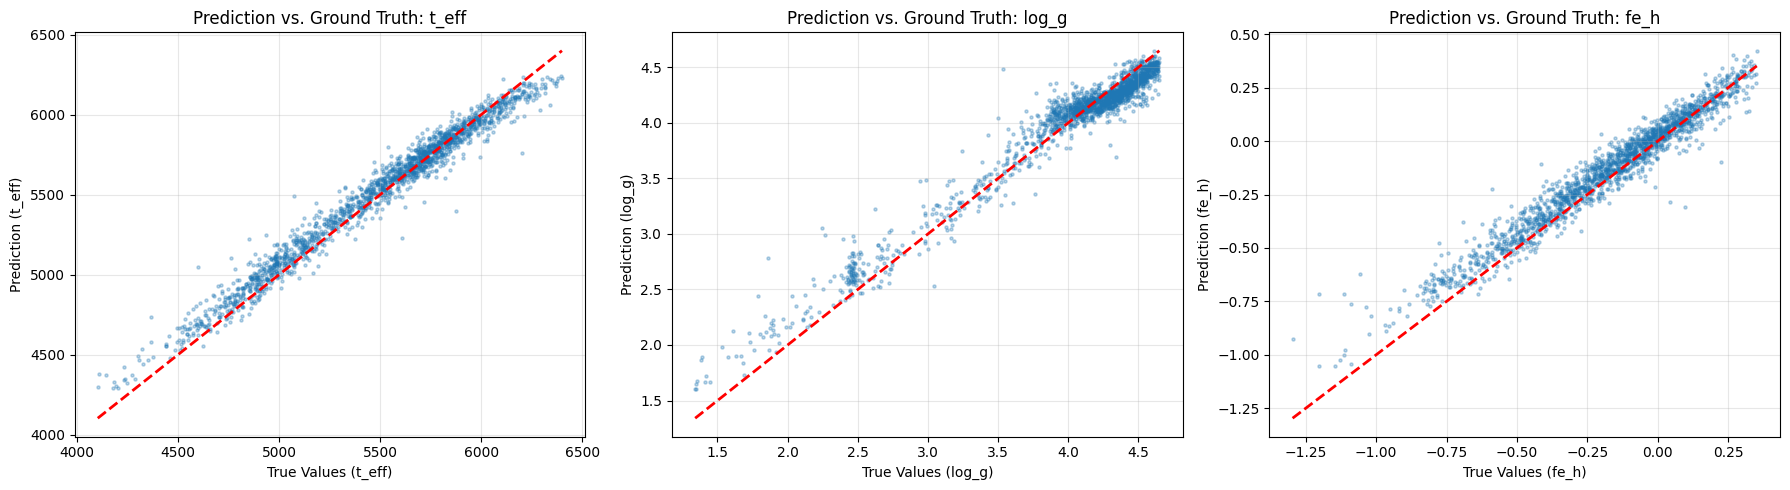

In [ ]:
'''
==========================================
6. Evaluation & Performance Documentation
==========================================
Generate predictions for the full test set
'''

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        preds = model(inputs).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets.numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# Inverse-transform data back to original physical units
preds_original = scaler.inverse_transform(all_preds)
targets_original = scaler.inverse_transform(all_targets)

# Scatter plots: prediction vs. ground truth
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(label_names):
    ax = axes[i]
    # Ideal reference line
    min_val = np.min(targets_original[:, i])
    max_val = np.max(targets_original[:, i])
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, zorder=2)

    # Scatter plot
    ax.scatter(targets_original[:, i], preds_original[:, i], alpha=0.3, s=5, zorder=1)

    ax.set_title(f"Prediction vs. Ground Truth: {name}")
    ax.set_xlabel(f"True Values ({name})")
    ax.set_ylabel(f"Prediction ({name})")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

These three scatter plots evaluate the model's final predictive performance on unseen test data. The x-axis represents the true physical values from the dataset, and the y-axis represents the model's predictions. The red dashed line denotes a "perfect prediction" scenario. The tighter the scatter clusters around this red line, the more accurate the model is for that specific stellar parameter.